# Task Performance
This data analysis report presents the descriptive and visual analysis as well as the results regarding the participant's task performance from the test session of the Masters' thesis *Recreation for all: Making Nature-Based Accommodations Discoverable for Public Transport Users*. The report includes code blocks, explanations, and the descriptive and visual results. 

Task performance is a multi-dimensional construct consisting of three categories: *Task Success*, *Task Solution Quality*, and *Task Solution Difficulty*. The report focuses on the analysis and results only. Background information and the discussion of results can be accessed from the written thesis document.

*Alischa Thomas - 2025 - Aalto University*

------------------

Project Setup
- Language: Python
- Virtual Environment: Conda. Packages were installed in the environment and only need to be imported to the script via the cells below.
- Juypter Notebook
- Github

---

# Preparation

In [41]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch # used to create filled shapes for plots
from matplotlib.lines import Line2D # used to create lines and dots for plots


## Creating and Cleaning Dataset
The following code block imports and prepares the data for further analysis. The original data can found in the xlsx file that is imported in the code from the src folder. The file can be found in the Github repo. Preparation steps include: transposing the data, cleaning up column names, removing data that's not needed.

In [80]:
# --Import the raw data and create a dataframe--

# --store csv to dataframe--
df_task_performance = pd.read_csv("src/raw_data_task_performance_working_file.csv")

# --Inspect dataframe--
# df_reachability
# check data type for cells
df_task_performance.dtypes

# --Transpose dataframe--
df_task_performance_trans = df_task_performance.T
# df_task_performance_trans

# --Clean column names--
col_names = ["Task_success", "Min_pref", "Max_pref", "Expected", "Actual", "Diff_expected_actual", "Task_start", "Task_end", "Task_conduction_time", "Platform_count", "Mental_load"]
# col_names
df_task_performance_trans.columns = col_names

# --Remove unrequired columns and rows--
df_task_performance_trans = df_task_performance_trans.drop(index=["Variable"])
df_task_performance_trans = df_task_performance_trans.drop(columns=["Task_start", "Task_end"])
df_task_performance_trans
# Calculate deviation in %
# df_task_performance_trans.dtypes

# --Inspect data types per col--
df_types = df_task_performance_trans.map(type)
df_types

# --Convert data types for further analysis--
cols_to_numeric = ["Min_pref", "Max_pref", "Expected", "Actual", "Diff_expected_actual", "Platform_count", "Mental_load"]
df_task_performance_trans[cols_to_numeric] = df_task_performance_trans[cols_to_numeric].apply(pd.to_numeric)
# converts conduction time to datetime in min format
df_task_performance_trans["Task_conduction_time"] = df_task_performance_trans["Task_conduction_time"].apply(pd.to_datetime).dt.time
#df_task_performance_trans["Task conduction time"] = pd.to_datetime(df_task_performance_trans["Task conduction time"]).dt.time
df_task_performance_trans["Task_success"] = df_task_performance_trans["Task_success"].map({"T": True, "F": False}) # converts cells for Task_success to T/F Boolean
df_types = df_task_performance_trans.map(type) # inspect new data types
df_types

# --Show new dataframw with converted types--
df_task_performance_trans


,Task_success,Min_pref,Max_pref,Expected,Actual,Diff_expected_actual,Task_conduction_time,Platform_count,Mental_load
P1,True,60,180,150,162,12,00:14:03,2,32
P2,False,60,210,150,207,57,00:30:30,7,85
P3,True,60,240,240,271,31,00:18:23,4,32
P4,True,90,420,250,296,46,00:22:25,6,25
P5,True,15,120,120,153,33,00:08:57,4,38
P6,True,30,150,80,85,5,00:20:50,3,30
P7,True,40,180,180,184,4,00:19:10,5,57


## Styles

In [170]:
col_orange = '#FFB14E'
col_pink = '#E14A99'
col_violet = '#C67CE8'

fontsize_plot_title = 14
fontsize_plot_description = 7
fontsize_axis_labels = 9


plot_title_position="center"

______________

## Analysis

### <span style="color:#C67CE8">Category 1 - Task Success</span> 
Task success is a binary variable: Success or fail. **6 / 7** participants successfully finished the task in the test session. 

### <span style="color:#C67CE8">Category 2 - Task Solution Quality</span> 
How does the reachability of the trip perform in relation to the participants preferences?

#### Data Preparation
Preparation steps include: extracting relevant data from the original dataframe, calculating average values for additional statistical insight, improving column names and row names. The output is a clean data set which serves as an input for the visual analysis.

In [98]:
#--Create subset of dataframe--
df_task_quality = df_task_performance_trans[["Min_pref", "Max_pref", "Expected", "Actual"]]
# df_task_quality

# Calculate deviation in %
df_task_quality["Diff_Actual_Expected"] = (df_task_quality["Actual"] - df_task_quality["Expected"]) / df_task_quality["Expected"] * 100

# --Add a row with average values--
# calculates average per col
avg = df_task_quality[["Min_pref", "Max_pref", "Expected", "Actual", "Diff_Actual_Expected"]].mean()
df_task_quality = pd.concat([ # concatenate is used to merge two dataframes which we use here to merge the row
    df_task_quality, # names first dataframe for merge
    pd.DataFrame([{ # creates second dataframe for merge from calculated average values. Assing each value to the existing columns in the new row
        "Min_pref": avg.Min_pref ,
        "Expected": avg.Expected,
        "Actual": avg.Actual,
        "Max_pref": avg.Max_pref,
        "Diff_Actual_Expected": avg.Diff_Actual_Expected,
    }])
], ignore_index=False).round(2)

# --renames index values to show participants--
df_task_quality.index = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "Avg."]


/var/folders/_9/bgdtlddx52v749qmr4d0z9tr0000gn/T/ipykernel_64494/3185376579.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_task_quality["Diff_Actual_Expected"] = (df_task_quality["Actual"] - df_task_quality["Expected"]) / df_task_quality["Expected"] * 100


#### Table: Travel Time to Accommodation (minutes)
The table presents different measures of the preferred, expected, and actual travel time to an accommodation.

1. Participant's general preference for the travel time for a short trip:
- Participant's minimum preferred travel time
- Participant's maximum preferred travel time

2. Travel time related to the specific accommodation selected in the test session:
- Participant's expected travel time** to the accommodation
- Actual travel time to the accommodation, which was validated by the researcher after the test session

In [99]:
# Result: dataframe for task quality
df_task_quality_sorted = df_task_quality.sort_values("Diff_Actual_Expected", ascending=False)
df_task_quality_sorted
#df_task_quality

,Min_pref,Max_pref,Expected,Actual,Diff_Actual_Expected
P2,60.00,210.00,150.00,207.0,38.00
P5,15.00,120.00,120.00,153.0,27.50
P4,90.00,420.00,250.00,296.0,18.40
Avg.,50.71,214.29,167.14,194.0,16.18
P3,60.00,240.00,240.00,271.0,12.92
P1,60.00,180.00,150.00,162.0,8.00
P6,30.00,150.00,80.00,85.0,6.25
P7,40.00,180.00,180.00,184.0,2.22


#### Plot 1: Travel Time to Accommodation (minutes)
For the visual analysis, the travel-time related data are triangulated in one plot. The visual analysis explores the relation between the participant's general preferences vs. the resulting travel time from the test session. The input for the plot is the cleaned data set from the previous step.

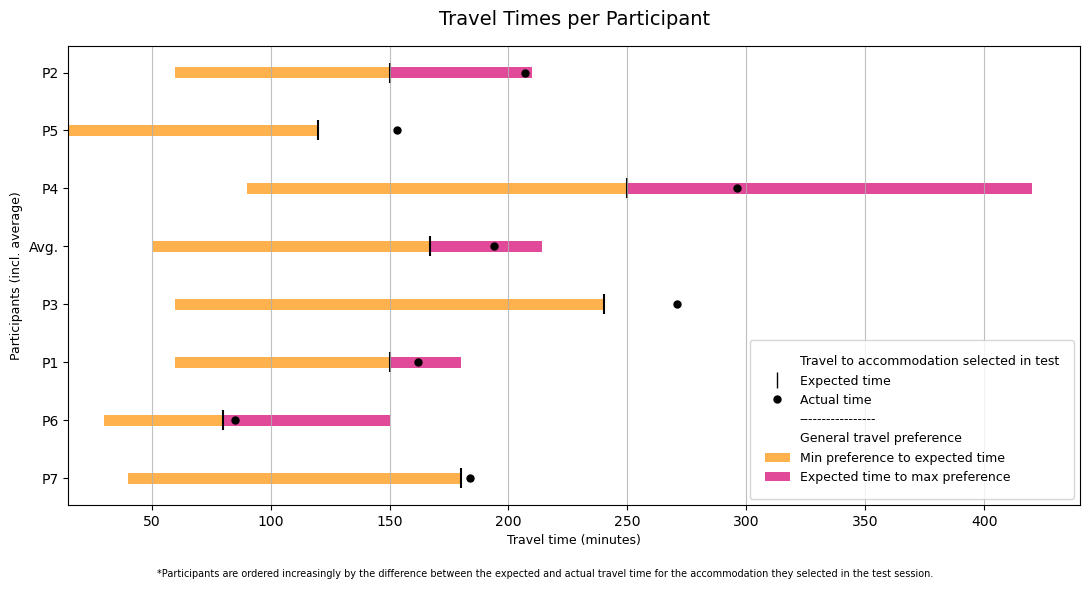

In [204]:
# create figure
plt.figure(figsize=(11, 6))

# y_pos tells matplotlib where to put the bars: on evenly spaced rows
y_pos = np.arange(len(df_task_quality_sorted))

# for each variable for each participant, the bars and markers are created:
for i, row in df_task_quality_sorted.iterrows():
    # Generates first segment of a row
    plt.barh(
        y=i, # y = participants
        width=row["Expected"] - row["Min_pref"], # width of the the first row segment: Expected travel time - minimum preferred travel time
        left=row["Min_pref"], # starting point on the left side of the first row segment
        height=0.2, # row height
        color=col_orange
    )

    # Generates second segment of a row
    plt.barh(
        y=i,
        width=row["Max_pref"] - row["Expected"], #width of the the second row segment: Expected travel time - maximum preferred travel time = 
        left=row["Expected"], # starting point on the left side of the first row segment
        height=0.2, # row height
        color= col_pink
    )

    # Add markers for expected travel time for trip and actual travel time
    #plt.scatter(row["Min_pref"], i, marker="|", s=100, color="black") # uncomment to show a marker for minumum preference
    plt.scatter(row["Expected"], i, marker="|", s=200, color="black")
    plt.scatter(row["Actual"], i, marker=".", s=100, color="black")
    #plt.scatter(row["Max_pref"], i, marker="|", s=100, color="black") # uncomment to show a marker for minumum preference

# --adds graph attributes: title, legend, ticks--
# title
plt.title("Travel Times per Participant", 
          fontsize=fontsize_plot_title, 
          loc=plot_title_position,
          pad=15
          ) 

# legend
# Create empty handles for legend headers 
header_general_preference = Patch(facecolor='none', edgecolor='none', label="General travel preference") 
header_test_session = Patch(facecolor='none', edgecolor='none', label="Travel to accommodation selected in test") 
header_empty_line = Patch(facecolor='none', edgecolor='none', label="-----------------") 


legend_elements = [
    header_test_session,
    Line2D([0], [0], marker='|', color='black', linestyle='None',
           markersize=12, label="Expected time"),
    Line2D([0], [0], marker='.', color='black', linestyle='None',
           markersize=10, label="Actual time"),
    header_empty_line,
    header_general_preference,
    Patch(facecolor=col_orange, label="Min preference to expected time"),
    Patch(facecolor=col_pink, label="Expected time to max preference"),
]

plt.legend(handles=legend_elements, loc="lower right", fontsize=fontsize_axis_labels, borderpad=1.2)

# description
plt.figtext(
    0.5, 0.03,
    "*Participants are ordered increasingly by the difference between the expected and actual travel time "
    "for the accommodation they selected in the test session.",
    ha="center",
    fontsize=fontsize_plot_description
)

# ticks
plt.yticks(y_pos, df_task_quality_sorted.index) # add ticks on y axis

# labels
plt.xlabel("Travel time (minutes)", fontsize=fontsize_axis_labels) # add x-axis label
plt.ylabel("Participants (incl. average)", fontsize=fontsize_axis_labels)

# layout
plt.grid(axis="x", linestyle="-", alpha=0.8)
plt.gca().invert_yaxis() # gets the current axis and inverts it so that the Average is shown at the bottom
plt.tight_layout()

# uncomment to adjust spacings around the plot
plt.subplots_adjust( 
    #left=0.13,
    bottom=0.15,
    #right=0.9,
    #top=0.9,
)

# save and show figure
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()

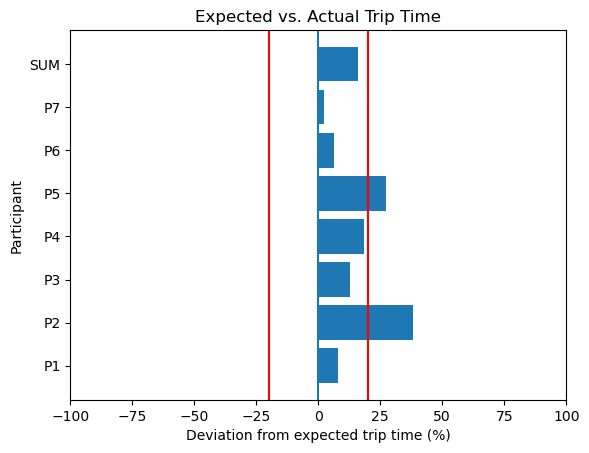

In [ ]:



plt.figure()
# creates horizontal bar
plt.barh(df_task_quality.index, df_task_quality["Deviation"])
# creates vertical line at 0
plt.axvline(0)
plt.axvline(20, color="r")
plt.axvline(-20, color="r")
# sets x-axis limits                
plt.xlim(-100, 100)
#plt.scatter(df_task_quality["20_Percent_Deviation_Threshold"], df_task_quality.index, marker="|", s=200, color="black")


plt.xlabel("Deviation from expected trip time (%)")
plt.ylabel("Participant")
plt.title("Expected vs. Actual Trip Time")
plt.savefig('3_1_task_solution_quality_deviation_expected_vs_actual_trip_time.png')
plt.show()
# df_task_quality


### <span style="color:#C67CE8">Category 3 - Task Difficulty</span> 

#### Data Preparation

In [ ]:
# Create subset of dataframe
df_task_effort = df_task_performance_trans[["Task_conduction_time", "Platform_count", "Mental_load"]]
df_task_effort.map(type)

# converts datetime to actual minutes format to calculate mean of conduction time
df_task_effort["Task_conduction_time_min"] = df_task_effort["Task_conduction_time"].apply(
    lambda t: t.hour * 60 + t.minute + t.second / 60
).round(2)

# drop old datetime column
df_task_effort = df_task_effort.drop(columns=["Task_conduction_time"])

# Add average row
# calculates average per col
avg = df_task_effort[["Task_conduction_time_min", "Platform_count", "Mental_load"]].mean()
df_task_effort = pd.concat([ # concatenate is used to merge two dataframes which we use here to merge the row
    df_task_effort, # names first dataframe for merge
    pd.DataFrame([{ # creates second dataframe for merge from calculated average values. Assing each value to the existing columns in the new row
        "Task_conduction_time_min": avg.Task_conduction_time_min ,
        "Platform_count": avg.Platform_count,
        "Mental_load": avg.Mental_load,
    }])
], ignore_index=False).round(2)

# renames index values to show sum
df_task_effort.index = ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "SUM"]

x_pos = np.arange(len(df_task_effort))
df_task_effort


/var/folders/_9/bgdtlddx52v749qmr4d0z9tr0000gn/T/ipykernel_12955/485341360.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_task_effort["Task_conduction_time_min"] = df_task_effort["Task_conduction_time"].apply(


,Platform_count,Mental_load,Task_conduction_time_min
P1,2.00,32.00,14.05
P2,7.00,85.00,30.50
P3,4.00,32.00,18.38
P4,6.00,25.00,22.42
P5,4.00,38.00,8.95
P6,3.00,30.00,20.83
P7,5.00,57.00,19.17
SUM,4.43,42.71,19.19


#### Plot

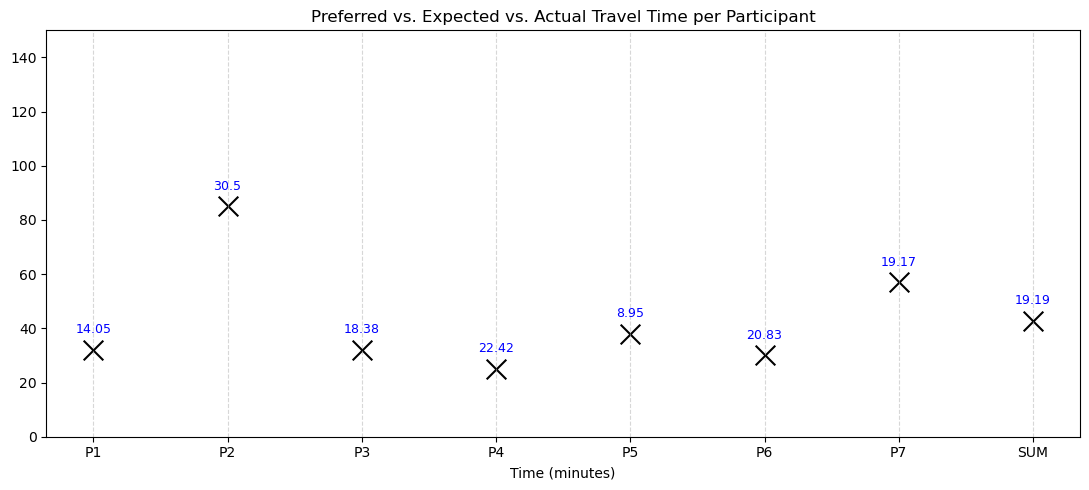

In [95]:
plt.figure(figsize=(11, 5))

# Markers
plt.scatter(df_task_effort.index, df_task_effort["Mental_load"], marker="x", s=200, color="black")
plt.ylim(0,150)

# annotate conduction time labels on top of mental load markers
for i, row in df_task_effort.iterrows():
    plt.text(
        i, # x-position
        row["Mental_load"] + 5,   # y-position
        row["Task_conduction_time_min"], # label text with 1 decimal
        ha='center', va='bottom', fontsize=9, color='blue'
    )

#plt.yticks(x_pos, df_task_quality.index)
plt.xlabel("Time (minutes)")
plt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()

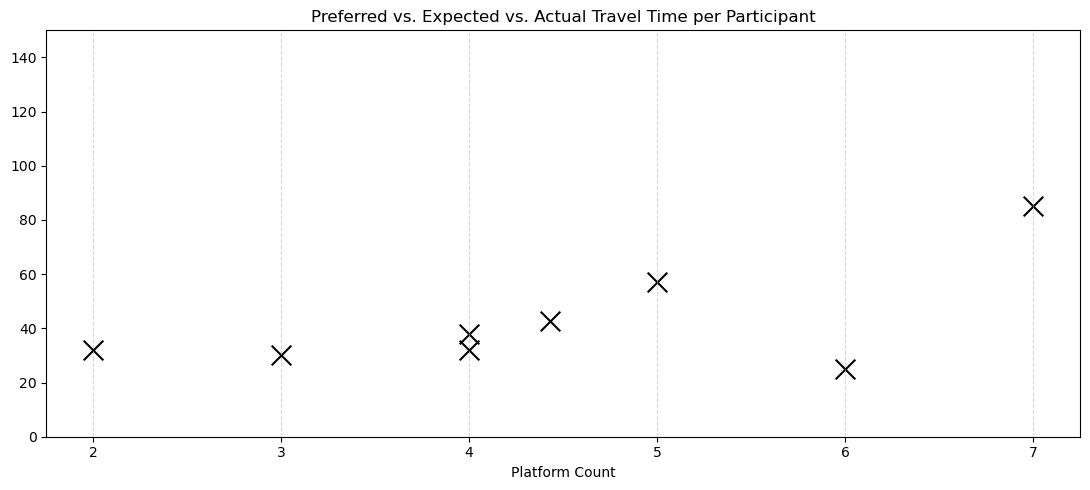

In [97]:
plt.figure(figsize=(11, 5))

# Markers
plt.scatter(df_task_effort["Platform_count"], df_task_effort["Mental_load"], marker="x", s=200, color="black")
plt.ylim(0,150)


#plt.yticks(x_pos, df_task_quality.index)
plt.xlabel("Platform Count")
plt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()

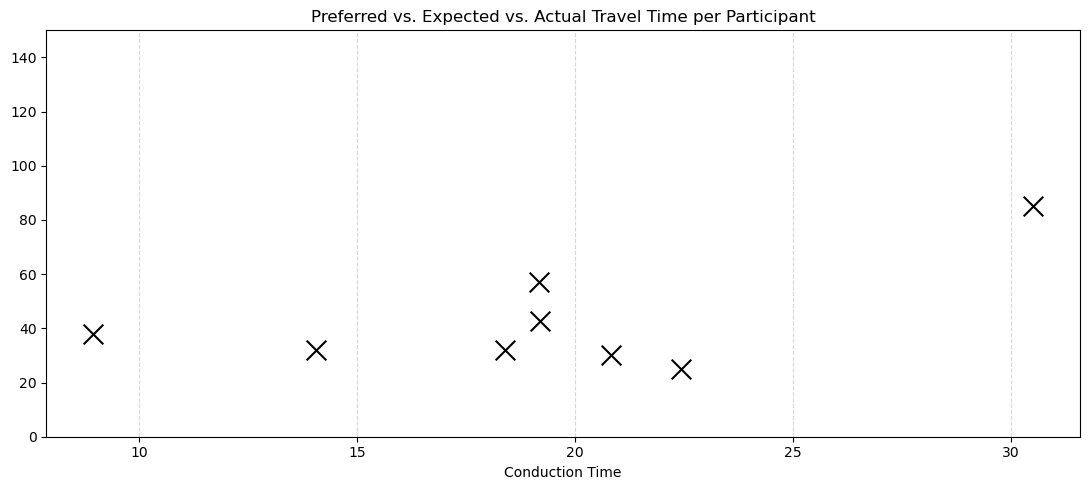

In [98]:
plt.figure(figsize=(11, 5))

# Markers
plt.scatter(df_task_effort["Task_conduction_time_min"], df_task_effort["Mental_load"], marker="x", s=200, color="black")
plt.ylim(0,150)


#plt.yticks(x_pos, df_task_quality.index)
plt.xlabel("Conduction Time")
plt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()

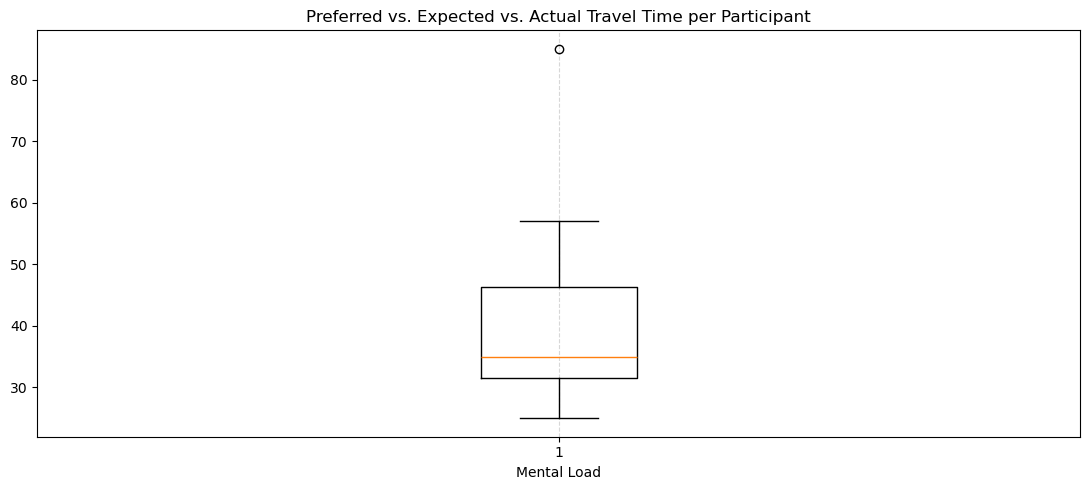

In [99]:
plt.figure(figsize=(11, 5))

# Markers
plt.boxplot(df_task_effort["Mental_load"])


#plt.yticks(x_pos, df_task_quality.index)
plt.xlabel("Mental Load")
plt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()

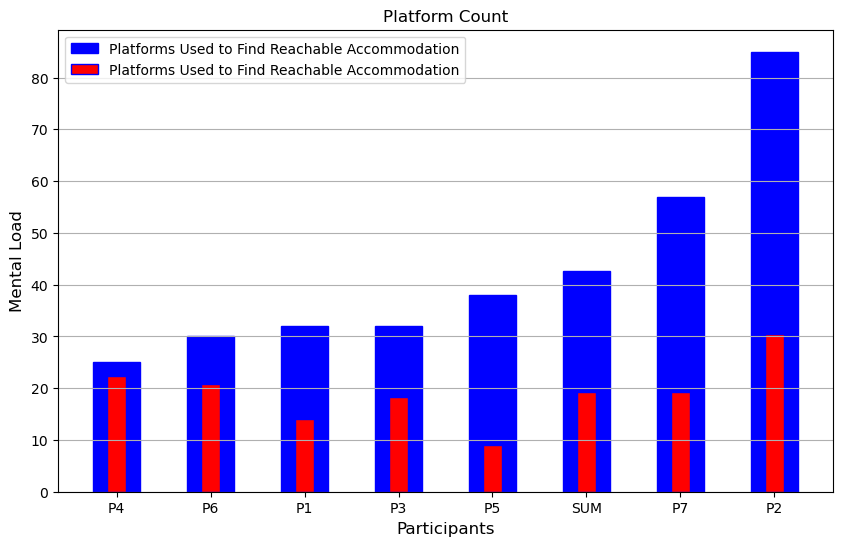

In [102]:
# sorts df for mental load
df_task_effort_sorted_mental = df_task_effort.sort_values("Mental_load")
plt.figure(figsize=(10, 6))

# Make the plot
plt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Mental_load"], color ='blue', width = 0.5,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')

plt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Task_conduction_time_min"], color ='red', width = 0.2,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')

plt.ylabel('Mental Load', fontsize = 12)
plt.xlabel('Participants', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()

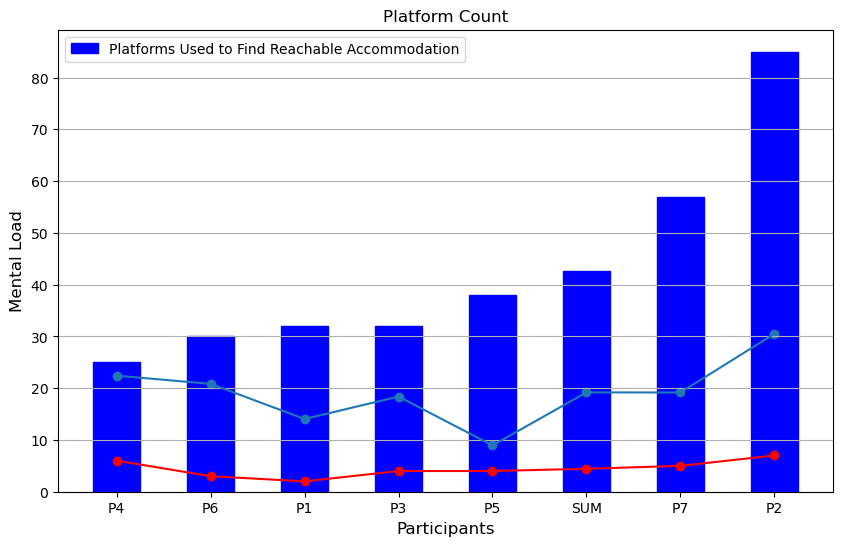

In [107]:
# sorts df for mental load
df_task_effort_sorted_mental = df_task_effort.sort_values("Mental_load")
plt.figure(figsize=(10, 6))

# Make the plot
plt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Mental_load"], color ='blue', width = 0.5,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')
plt.plot(
    df_task_effort_sorted_mental.index,
    df_task_effort_sorted_mental["Task_conduction_time_min"])

plt.scatter(
    df_task_effort_sorted_mental.index,
    df_task_effort_sorted_mental["Task_conduction_time_min"], marker="o"
)

plt.plot(
    df_task_effort_sorted_mental.index,
    df_task_effort_sorted_mental["Platform_count"], color="r")

plt.scatter(
    df_task_effort_sorted_mental.index,
    df_task_effort_sorted_mental["Platform_count"], marker="o", color="r"
)

plt.ylabel('Mental Load', fontsize = 12)
plt.xlabel('Participants', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()

/var/folders/_9/bgdtlddx52v749qmr4d0z9tr0000gn/T/ipykernel_12955/141723313.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


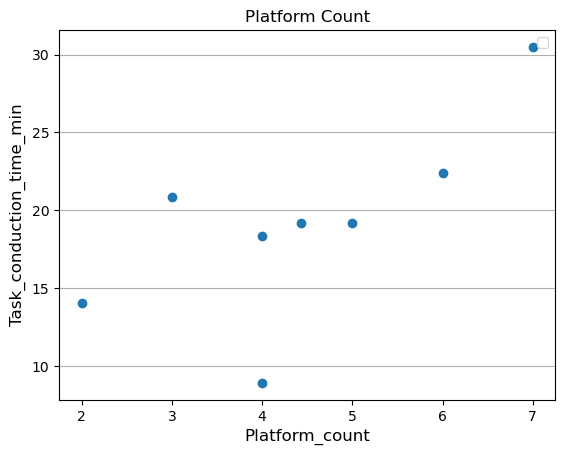

In [ ]:
# Make the plot

plt.scatter(
    df_task_effort_sorted_mental["Platform_count"], 
        df_task_effort_sorted_mental["Task_conduction_time_min"], marker="o",
)


plt.ylabel('Task_conduction_time_min', fontsize = 12)
plt.xlabel('Platform_count', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()

#### SMEQ - Subjective Mental Effort

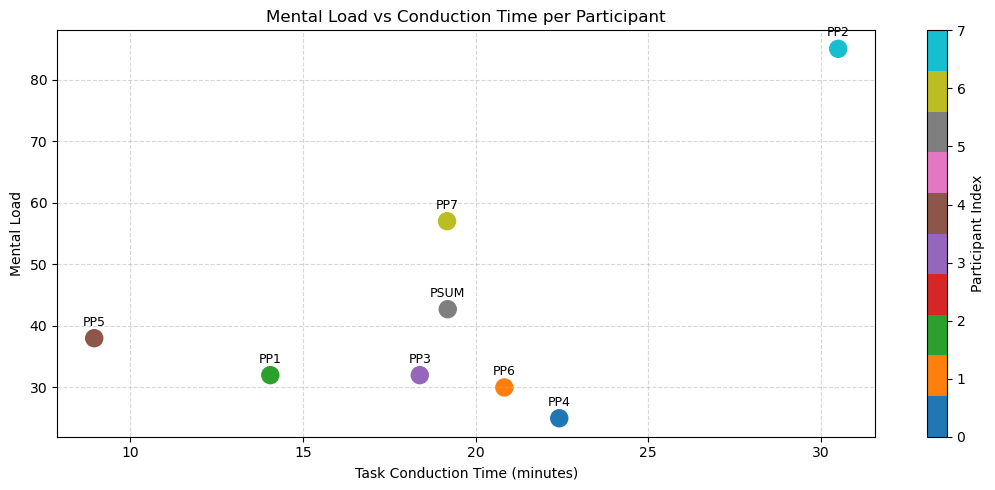

In [111]:

plt.figure(figsize=(11, 5))
participant_codes = {p: i for i, p in enumerate(df_task_effort.index)}
df_task_effort_sorted_mental["participant_code"] = df_task_effort.index.map(participant_codes)

# Scatter: conduction time vs mental load
scatter = plt.scatter(
    df_task_effort_sorted_mental["Task_conduction_time_min"],  # X-axis
    df_task_effort_sorted_mental["Mental_load"],              # Y-axis
    c=df_task_effort_sorted_mental["participant_code"],                   # Color by participant (or assign a numeric ID)
    s=150,                                     # Marker size
    cmap='tab10',                               # Color map
    marker='o'
)

# Add participant labels on markers
for i, row in df_task_effort_sorted_mental.iterrows():
    plt.text(
        row["Task_conduction_time_min"], 
        row["Mental_load"] + 2, 
        f'P{row.name}',  # Or row["Participant"] if you have a column
        ha='center', 
        fontsize=9
    )

plt.xlabel("Task Conduction Time (minutes)")
plt.ylabel("Mental Load")
plt.title("Mental Load vs Conduction Time per Participant")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(scatter, label="Participant Index")  # optional
plt.tight_layout()
plt.show()


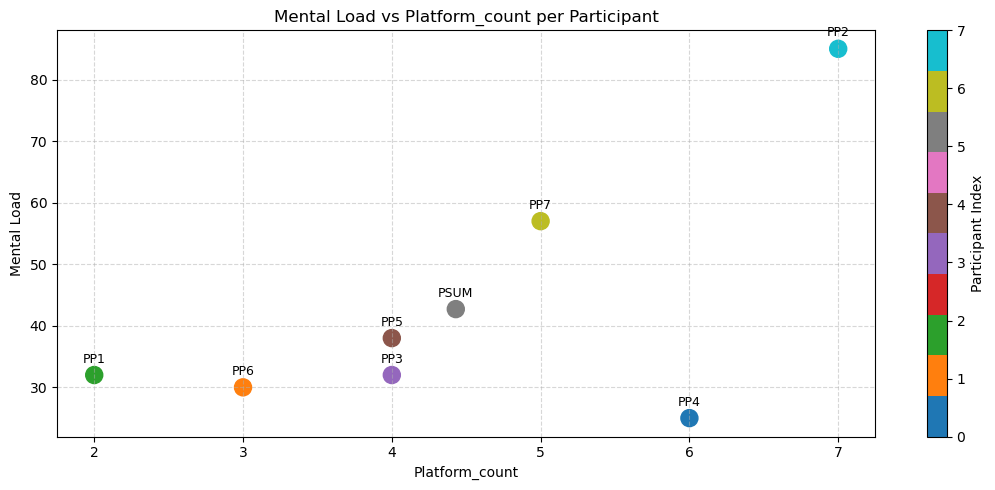

In [112]:
plt.figure(figsize=(11, 5))

# Scatter: conduction time vs mental load
scatter = plt.scatter(
    df_task_effort_sorted_mental["Platform_count"],  # X-axis
    df_task_effort_sorted_mental["Mental_load"],              # Y-axis
    c=df_task_effort_sorted_mental["participant_code"],                   # Color by participant (or assign a numeric ID)
    s=150,                                     # Marker size
    cmap='tab10',                               # Color map
    marker='o'
)

# Add participant labels on markers
for i, row in df_task_effort_sorted_mental.iterrows():
    plt.text(
        row["Platform_count"], 
        row["Mental_load"] + 2, 
        f'P{row.name}',  # Or row["Participant"] if you have a column
        ha='center', 
        fontsize=9
    )

plt.xlabel("Platform_count")
plt.ylabel("Mental Load")
plt.title("Mental Load vs Platform_count per Participant")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(scatter, label="Participant Index")  # optional
plt.tight_layout()
plt.show()

#### Platform Count

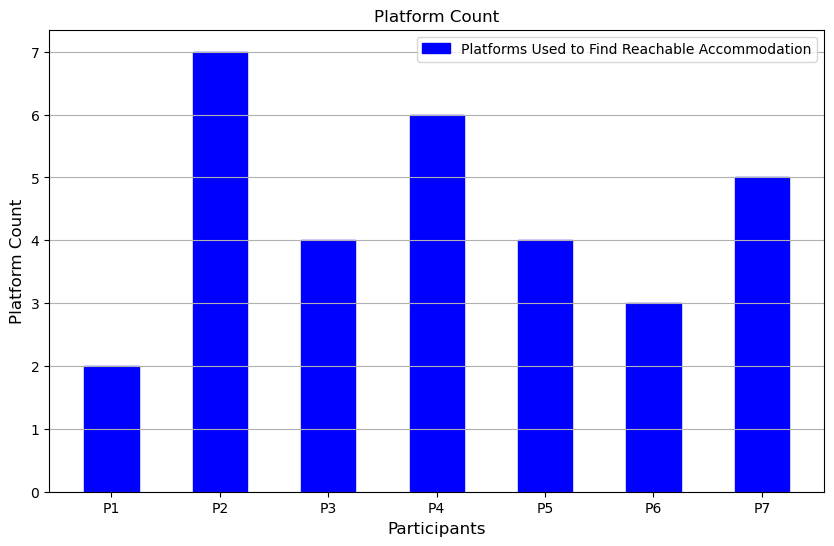

In [70]:
# Platform count
plt.figure(figsize=(10, 6))

# Make the plot
plt.bar(df_task_performance_trans.index, df_task_performance_trans["Platform count"], color ='blue', width = 0.5,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')

plt.ylabel('Platform Count', fontsize = 12)
plt.xlabel('Participants', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()